End-to-End E-commerce Intelligence System: Building a Customer 360 Analytics Framework 

In [16]:
#importing all the libararies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#print("All the libraries are imported successfully")


In [17]:
#load the dataset
orders = pd.read_csv("datasets/orders.csv")
customers = pd.read_csv("datasets/customers.csv")
products = pd.read_csv("datasets/products.csv")
reviews = pd.read_csv("datasets/reviews.csv")
payments = pd.read_csv("datasets/payments.csv")
sellers = pd.read_csv("datasets/sellers.csv")
locations = pd.read_csv("datasets/location.csv")
orders_items = pd.read_csv("datasets/order_item.csv")
category_translation = pd.read_csv("datasets/category_translation.csv")
#print ("All the datasets are loaded successfully")

In [18]:
#inspect the datasets
def inspect_dataset(df, name):
    print("\n" + "="*80)
    print(f"Dataset: {name}")
    print("="*80)
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    
    # Identify numerical and categorical fields
    numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    print(f"\nNumerical Fields: {numerical_cols}")
    print(f"Categorical Fields: {categorical_cols}")
    
    print("\n--- HEAD (First 5 rows) ---")
    print(df.head())
    
    print("\n--- TAIL (Last 5 rows) ---")
    print(df.tail())
    
    print("\n--- INFO ---")
    df.info()
    
    if numerical_cols:
        print("\n--- DESCRIBE (Numerical Fields) ---")
        print(df[numerical_cols].describe())
    
    if categorical_cols:
        print("\n--- DESCRIBE (Categorical Fields) ---")
        print(df[categorical_cols].describe())
        
        print("\n--- UNIQUE VALUE COUNTS (Categorical Fields) ---")
        for col in categorical_cols:
            print(f"\n{col}:")
            print(df[col].value_counts().head(10))  # Top 10 for brevity
    
    print("\n--- MISSING VALUES ---")
    print(df.isnull().sum())
    
    print("\n--- DUPLICATE ROWS ---")
    print(f"Number of duplicate rows: {df.duplicated().sum()}")
    
    print("-"*80)

# Dictionary of all datasets (already defined in previous cells)
datasets = {
    'Orders': orders,
    'Customers': customers,
    'Products': products,
    'Reviews': reviews,
    'Payments': payments,
    'Sellers': sellers,
    'Locations': locations,
    'Orders Items': orders_items,
    'Category Translation': category_translation
}

# Loop through each dataset and inspect
for name, df in datasets.items():
    inspect_dataset(df, name)


Dataset: Orders
Shape: (99441, 8)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Numerical Fields: []
Categorical Fields: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

--- HEAD (First 5 rows) ---
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \


# Identifying primary and foreign keys and Understanding relationships between datasets 

1. Primary Keys for each dataset
    - customers dataset: customer_id
    - orders dataset: order_id
    - products dataset: product_id
    - sellers dataset: seller_id
    - reviews dataset: review_id
    - location dataset: geolocation_zip_code_prefix
    - category_translation dataset: product_category_name
    - order_item dataset: order_id + order_item_id #cause one order can have multiple items.
    - payments dataset: order_id + payment_sequential #cause one order can be paid for using multiple methods, like a voucher plus a credit card.

2. Foreign keys and Relationships
    - Connections to the orders dataset:
        * *Customers to orders:* Connected by `customer_id`. *(who made the order).*
        * *Order_items to orders:* Connected by `order_id`. *(what specific items are inside the order).*
        * *Payments to orders:* Connected by `order_id`. *(how the order was paid for).*
        * *Reviews to orders:* Connected by `order_id`. *(gives the customer's feedback on that specific order).*

    - Connections branching out from Order Items:
        * *Products to Order Items:* Connected by `product_id`. *(gives the details, size, and category of the item bought).*
        * *Sellers to Order Items:* Connected by `seller_id`. *(which third-party seller supplied the item).*

    - Connections for Mapping & Translation:
        * *Location to Customers:* Connected by zip code (`customer_zip_code_prefix` matches `geolocation_zip_code_prefix`).
        * *Location to Sellers:* Connected by zip code (`seller_zip_code_prefix` matches `geolocation_zip_code_prefix`).
        * *Category Translation to Products:* Connected by `product_category_name`. *(translates the Portuguese product categories into English).*

3. The Business Relationships (The Order Lifecycle)

    - The Checkout (Orders & Payments)
        A Customer initiates an Order. Because they might use multiple payment methods (like a credit card plus a discount voucher), the Payments table attaches to the order to record exactly how the revenue was collected.
    - The Shopping Cart (Order Items & Products)
        A single order is broken down into individual Order Items. These items link to the Products table so we can see the exact weight, size, and category of the merchandise sold. The Category Translation table connects directly to the products, converting the categories into standard English for clear business reporting.
    - The Supply Chain (Sellers & Locations)
        Every item purchased is matched to a specific Seller responsible for fulfillment. By running both the Customer’s and the Seller’s zip codes through the Locations table, we can track the physical delivery route across the country.
    - The Customer Satisfaction (Reviews)
        Once the delivery is complete, the customer leaves a rating. The Reviews table connects back to the original Order, allowing us to link a 5-star or 1-star rating directly to the specific product bought and the seller who shipped it.



In [19]:
#Data Cleaning and Preprocessing for each dataset
print("Starting Individual Dataset Cleaning...\n")

# ==========================================
# 1. Clean Orders Dataset
# ==========================================
def clean_orders(df):
    df_clean = df.copy()
    # Convert dates
    date_cols = ['order_purchase_timestamp', 'order_approved_at', 
                 'order_delivered_carrier_date', 'order_delivered_customer_date', 
                 'order_estimated_delivery_date']
    for col in date_cols:
        df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
    
    # Business Logic: We do NOT drop rows with missing delivery dates, 
    # as these represent canceled or in-transit orders.
    df_clean = df_clean.drop_duplicates()
    return df_clean

# ==========================================
# 2. Clean Reviews Dataset
# ==========================================
def clean_reviews(df):
    df_clean = df.copy()
    # Convert dates
    df_clean['review_creation_date'] = pd.to_datetime(df_clean['review_creation_date'], errors='coerce')
    df_clean['review_answer_timestamp'] = pd.to_datetime(df_clean['review_answer_timestamp'], errors='coerce')
    
    # Handle Missing Values: Preserve the numeric score, fill missing text
    df_clean['review_comment_title'] = df_clean['review_comment_title'].fillna('No Title')
    df_clean['review_comment_message'] = df_clean['review_comment_message'].fillna('No Comment')
    
    # Validate Ranges: Ensure scores are strictly between 1 and 5
    df_clean = df_clean[df_clean['review_score'].between(1, 5)]
    
    df_clean = df_clean.drop_duplicates()
    return df_clean

# ==========================================
# 3. Clean Products Dataset
# ==========================================
def clean_products(df):
    df_clean = df.copy()
    # Standardize column names (Fixing Portuguese/English typos)
    df_clean = df_clean.rename(columns={
        'product_name_lenght': 'product_name_length',
        'product_description_lenght': 'product_description_length'
    })
    
    # Handle Missing Values
    df_clean['product_category_name'] = df_clean['product_category_name'].fillna('unknown_category')
    
    # Impute numeric specifications with median to avoid outlier skew
    numeric_cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
    for col in numeric_cols:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        
    df_clean = df_clean.drop_duplicates()
    return df_clean

# ==========================================
# 4. Clean Order Items & Payments (Financials)
# ==========================================
def clean_financials(items_df, payments_df):
    items_clean = items_df.copy()
    payments_clean = payments_df.copy()
    
    # Convert dates
    items_clean['shipping_limit_date'] = pd.to_datetime(items_clean['shipping_limit_date'], errors='coerce')
    
    # Validate Types and Ranges (Prices and Payments cannot be negative)
    items_clean['price'] = pd.to_numeric(items_clean['price'], errors='coerce')
    items_clean = items_clean[items_clean['price'] >= 0]
    
    payments_clean['payment_value'] = pd.to_numeric(payments_clean['payment_value'], errors='coerce')
    payments_clean = payments_clean[payments_clean['payment_value'] >= 0]
    
    return items_clean.drop_duplicates(), payments_clean.drop_duplicates()

# ==========================================
# 5. Clean Locations (Crucial for Merge Accuracy)
# ==========================================
def clean_locations(df):
    df_clean = df.copy()
    # The geolocation table often has multiple identical zip codes with slightly different coordinates.
    # We must group by zip code and take the first one, or merging will create millions of duplicate orders.
    df_clean = df_clean.drop_duplicates(subset=['geolocation_zip_code_prefix'], keep='first')
    return df_clean

orders_clean = clean_orders(orders)
reviews_clean = clean_reviews(reviews)
products_clean = clean_products(products)
order_items_clean, payments_clean = clean_financials(orders_items, payments)
locations_clean = clean_locations(locations)
customers_clean = customers.drop_duplicates()
sellers_clean = sellers.drop_duplicates()
category_translation_clean = category_translation.drop_duplicates()

print("All individual datasets have been cleaned, validated, and deduplicated!")

Starting Individual Dataset Cleaning...

All individual datasets have been cleaned, validated, and deduplicated!


In [23]:
#creating a unified master dataset by merging all the cleaned datasets
def build_master_dataset(orders, customers, order_items, products, payments, reviews, sellers, category_translation):
    """
    Constructs the Master Customer 360 Dataset by merging 8 distinct tables.
    We use LEFT JOINS to ensure no core order data is lost even if a peripheral 
    event (like a review) is missing.
    """
    print("Starting Data Integration: Building Master Dataset...\n")
    
    # 1. orders + customers
    # Links the transaction to the buyer
    master_df = pd.merge(orders, customers, on='customer_id', how='left')
    print(f"1. Added Customers  -> Shape: {master_df.shape}")
    
    # 2. orders + order_items
    # Shifts the grain of the dataset from "Order Level" to "Item Level"
    master_df = pd.merge(master_df, order_items, on='order_id', how='inner')
    print(f"2. Added Items      -> Shape: {master_df.shape}")
    
    # 3. order_items + products
    # Brings in product dimensions, weights, and Portuguese categories
    master_df = pd.merge(master_df, products, on='product_id', how='left')
    print(f"3. Added Products   -> Shape: {master_df.shape}")
    
    # 4. orders + payments
    # Brings in financial data and payment methods.
    #using LEFT JOIN to preserve orders without payment records (e.g., canceled orders), ensuring a complete view of all transactions.
    master_df = pd.merge(master_df, payments, on='order_id', how='left')
    print(f"4. Added Payments   -> Shape: {master_df.shape}")
    
    # 5. orders + reviews
    # Brings in customer satisfaction scores
    master_df = pd.merge(master_df, reviews, on='order_id', how='left')
    print(f"5. Added Reviews    -> Shape: {master_df.shape}")
    
    # 6. order_items + sellers
    # Identifies the merchant responsible for fulfillment
    master_df = pd.merge(master_df, sellers, on='seller_id', how='left')
    print(f"6. Added Sellers    -> Shape: {master_df.shape}")
    
    # 7. products + category_translation
    # Standardizes reporting by mapping Portuguese categories to English
    master_df = pd.merge(master_df, category_translation, on='product_category_name', how='left')
    print(f"7. Added English Translations -> Shape: {master_df.shape}")
    
    print("\nData Integration Complete!")
    print(f"Final Master Dataset Shape: {master_df.shape}")
    print(f"Total Columns: {len(master_df.columns)}")
    
    return master_df

master_df = build_master_dataset(orders_clean, customers_clean, order_items_clean, 
                                  products_clean, payments_clean, reviews_clean, 
                                  sellers_clean, category_translation_clean)

master_df.head(5)
#master_df.columns


Starting Data Integration: Building Master Dataset...

1. Added Customers  -> Shape: (99441, 12)
2. Added Items      -> Shape: (112650, 18)
3. Added Products   -> Shape: (112650, 26)
4. Added Payments   -> Shape: (117604, 30)
5. Added Reviews    -> Shape: (118310, 36)
6. Added Sellers    -> Shape: (118310, 39)
7. Added English Translations -> Shape: (118310, 40)

Data Integration Complete!
Final Master Dataset Shape: (118310, 40)
Total Columns: 40


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,31570,belo horizonte,SP,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,e73b67b67587f7644d5bd1a52deb1b01,5.0,No Title,No Comment,2018-08-18,2018-08-22 19:07:58,14840,guariba,SP,auto


In [24]:
#exporting the master dataset to a csv file
master_df.to_csv("customer_360_view.csv", index=False)

In [25]:
#Feature Engineering on the master dataset

def engineer_features(master_df):
    """
    Generates derived features at both the Order Level and Customer Level.
    Safely handles aggregations to prevent double-counting revenue from JOIN explosions.
    """
    print("Starting Feature Engineering...")
    df = master_df.copy()

    # ==========================================
    # 1. Order-Level Features
    # ==========================================
    print(" -> Engineering Order-Level Metrics (Delivery Time, Basket Size)...")
    
    # Feature 1: Delivery Time (in days)
    # Calculates the total time from checkout to doorstep
    df['delivery_time_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
    
    # Feature 2: Number of items per order
    # Group by order_id and count unique order_item_ids
    items_per_order = df.groupby('order_id')['order_item_id'].nunique().reset_index()
    items_per_order.rename(columns={'order_item_id': 'num_items_in_order'}, inplace=True)
    
    # Feature 3: Total Order Value
    # To avoid double counting items vs payments, we isolate unique payments per order
    unique_payments = df.drop_duplicates(subset=['order_id', 'payment_sequential'])
    order_value = unique_payments.groupby('order_id')['payment_value'].sum().reset_index()
    order_value.rename(columns={'payment_value': 'total_order_value'}, inplace=True)

    # Merge Order features together
    order_features = pd.merge(items_per_order, order_value, on='order_id')
    
    # Merge back to our master dataframe
    df = pd.merge(df, order_features, on='order_id', how='left')

    # ==========================================
    # 2. Customer-Level Features (The 360 Profile)
    # ==========================================
    print(" -> Engineering Customer-Level Metrics (CLV, Frequency, AOV)...")
    
    # We map total order value to the specific, unique person (customer_unique_id)
    # We drop duplicates to ensure we only look at each order once per person
    customer_order_map = df[['customer_unique_id', 'order_id', 'total_order_value']].drop_duplicates()
    
    customer_profile = customer_order_map.groupby('customer_unique_id').agg(
        customer_purchase_frequency=('order_id', 'nunique'),     # Feature 4: Purchase Frequency
        customer_lifetime_value=('total_order_value', 'sum')     # Feature 5: CLV
    ).reset_index()
    
    # Feature 6: Average Order Value per Customer (AOV)
    customer_profile['average_order_value'] = (
        customer_profile['customer_lifetime_value'] / customer_profile['customer_purchase_frequency']
    ).round(2)

    # Merge customer features back to master dataframe
    df = pd.merge(df, customer_profile, on='customer_unique_id', how='left')
    
    print("Feature Engineering Complete!\n")
    return df, customer_profile, order_features

master_df_engineered, customer_360_profile, order_level_metrics = engineer_features(master_df)

print(customer_360_profile.head())

Starting Feature Engineering...
 -> Engineering Order-Level Metrics (Delivery Time, Basket Size)...
 -> Engineering Customer-Level Metrics (CLV, Frequency, AOV)...
Feature Engineering Complete!

                 customer_unique_id  customer_purchase_frequency  \
0  0000366f3b9a7992bf8c76cfdf3221e2                            1   
1  0000b849f77a49e4a4ce2b2a4ca5be3f                            1   
2  0000f46a3911fa3c0805444483337064                            1   
3  0000f6ccb0745a6a4b88665a16c9f078                            1   
4  0004aac84e0df4da2b147fca70cf8255                            1   

   customer_lifetime_value  average_order_value  
0                   141.90               141.90  
1                    27.19                27.19  
2                    86.22                86.22  
3                    43.62                43.62  
4                   196.89               196.89  


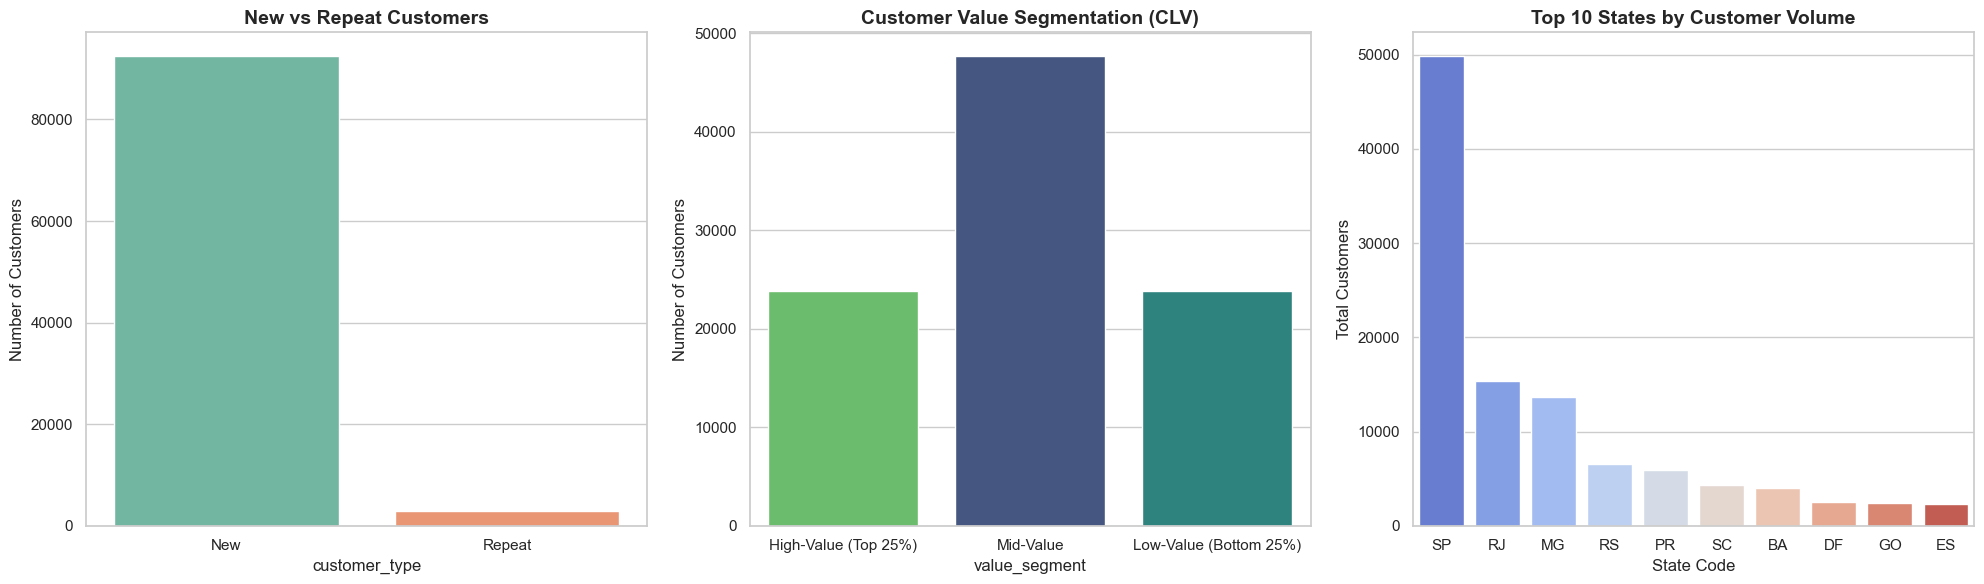

In [40]:
#EDA and Visualization for Customer Analysis
# Set standard aesthetic for all plots
sns.set_theme(style="whitegrid", palette="muted")

def analyze_customers(df, customer_profile):
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # 1. New vs Repeat Customers
    # Anyone with > 1 order is a repeat customer
    customer_profile['customer_type'] = np.where(customer_profile['customer_purchase_frequency'] > 1, 'Repeat', 'New')
    sns.countplot(data=customer_profile, x='customer_type', ax=axes[0], palette='Set2', hue='customer_type')
    axes[0].set_title('New vs Repeat Customers', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Number of Customers')
    
    # 2. High-Value vs Low-Value Customers (Using Quantiles on CLV)
    # Top 25% of spenders are High-Value, Bottom 25% are Low-Value, rest are Mid
    conditions = [
        customer_profile['customer_lifetime_value'] >= customer_profile['customer_lifetime_value'].quantile(0.75),
        customer_profile['customer_lifetime_value'] <= customer_profile['customer_lifetime_value'].quantile(0.25)
    ]
    choices = ['High-Value (Top 25%)', 'Low-Value (Bottom 25%)']
    customer_profile['value_segment'] = np.select(conditions, choices, default='Mid-Value')
    
    sns.countplot(data=customer_profile, x='value_segment', order=['High-Value (Top 25%)', 'Mid-Value', 'Low-Value (Bottom 25%)'], ax=axes[1], palette='viridis', hue='value_segment')
    axes[1].set_title('Customer Value Segmentation (CLV)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Number of Customers')
    
    # 3. Geographic Distribution (Top 10 States)
    top_states = df['customer_state'].value_counts().head(10)
    sns.barplot(x=top_states.index, y=top_states.values, ax=axes[2], palette='coolwarm', hue=top_states.index)
    axes[2].set_title('Top 10 States by Customer Volume', fontsize=14, fontweight='bold')
    axes[2].set_ylabel('Total Customers')
    axes[2].set_xlabel('State Code')
    
    plt.tight_layout()
    plt.show()


analyze_customers(master_df_engineered, customer_360_profile)

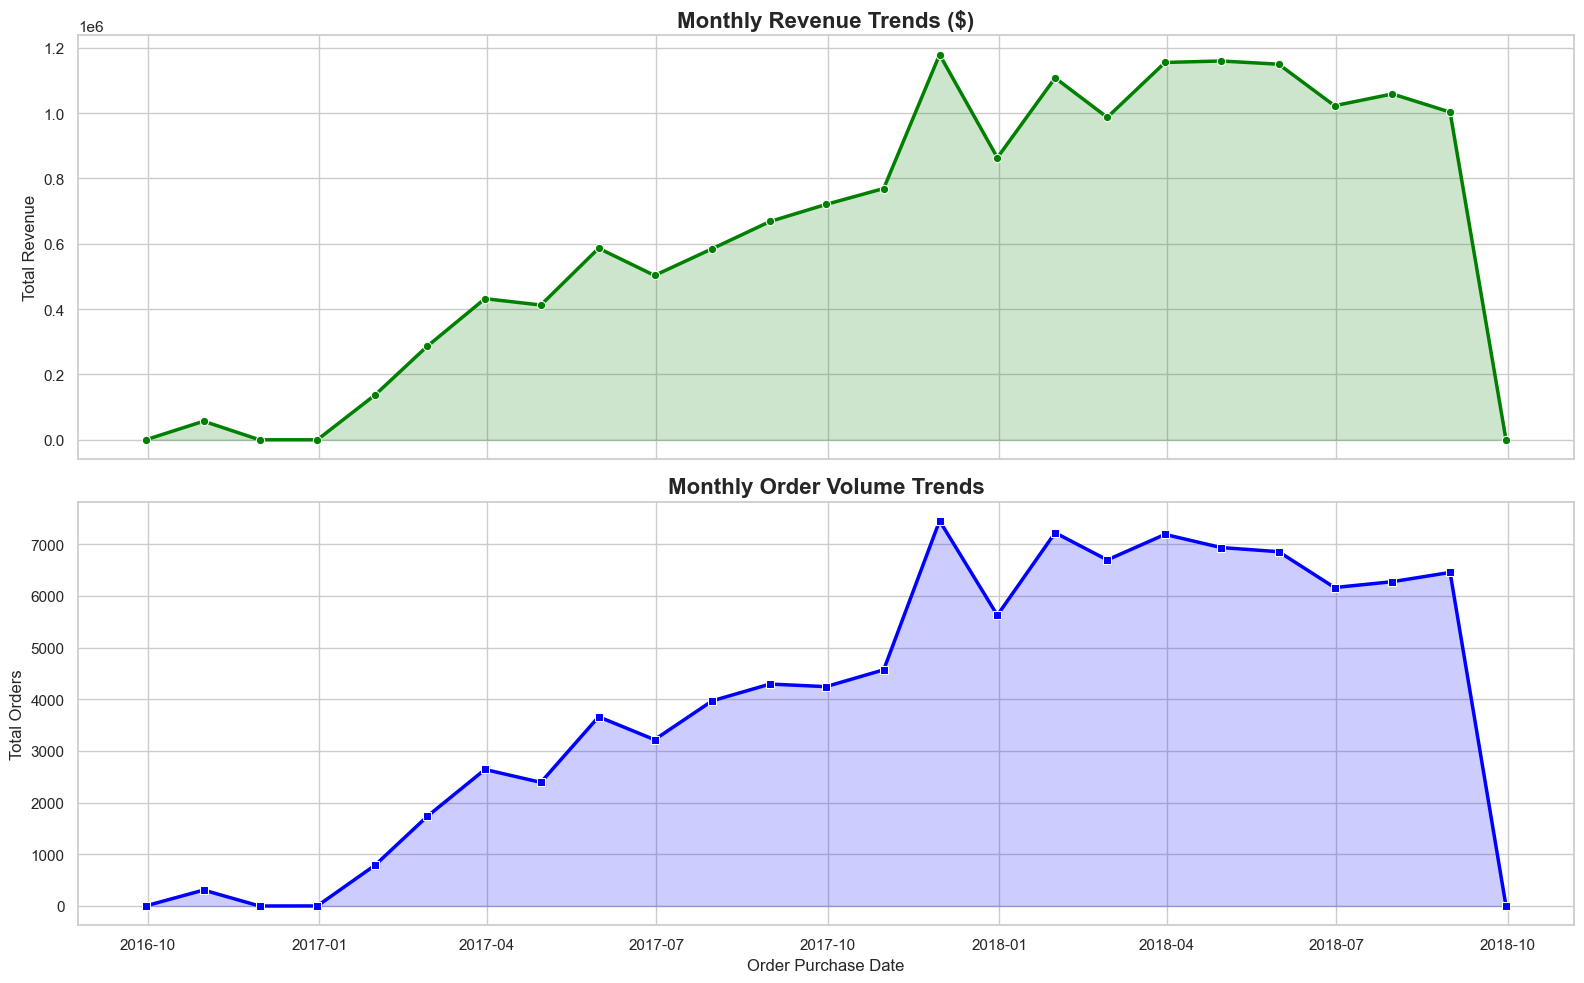

In [27]:
# EDA & Visualization for Revenue and Order anlysis
def analyze_revenue_trends(df):
    # Isolate unique orders to prevent revenue duplication from multiple items/payments
    order_level_df = df.drop_duplicates(subset=['order_id']).copy()
    order_level_df.set_index('order_purchase_timestamp', inplace=True)
    
    # Resample data by Month ('M')
    monthly_revenue = order_level_df.resample('ME')['total_order_value'].sum()
    monthly_volume = order_level_df.resample('ME')['order_id'].count()

    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
    
    # 1. Monthly Revenue Trends
    sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values, ax=axes[0], color='green', linewidth=2.5, marker='o')
    axes[0].set_title('Monthly Revenue Trends ($)', fontsize=16, fontweight='bold')
    axes[0].set_ylabel('Total Revenue')
    axes[0].fill_between(monthly_revenue.index, monthly_revenue.values, alpha=0.2, color='green')
    
    # 2. Monthly Order Volume Trends
    sns.lineplot(x=monthly_volume.index, y=monthly_volume.values, ax=axes[1], color='blue', linewidth=2.5, marker='s')
    axes[1].set_title('Monthly Order Volume Trends', fontsize=16, fontweight='bold')
    axes[1].set_ylabel('Total Orders')
    axes[1].set_xlabel('Order Purchase Date')
    axes[1].fill_between(monthly_volume.index, monthly_volume.values, alpha=0.2, color='blue')
    
    plt.tight_layout()
    plt.show()

analyze_revenue_trends(master_df_engineered)

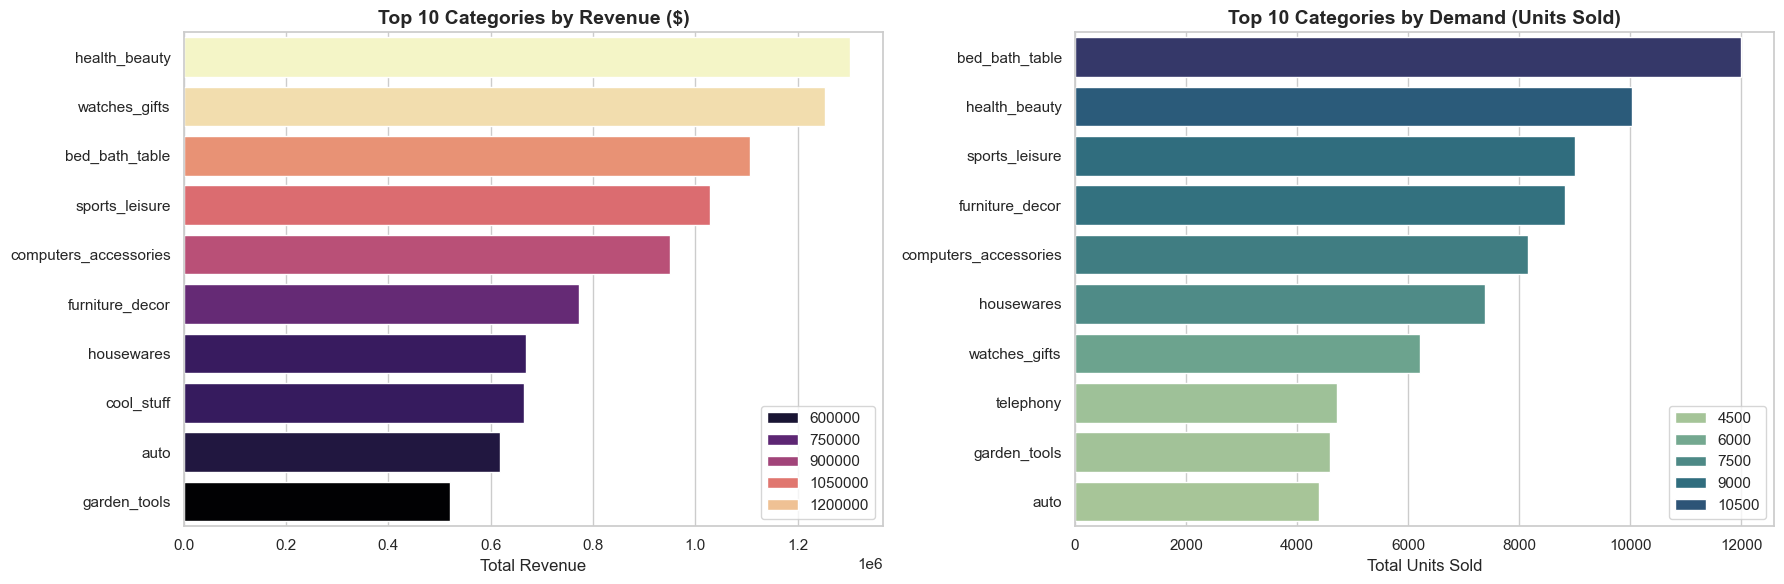

In [39]:
#EDA & Visualization for Product Analysis 
def analyze_products(df):
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Filter out 'unknown' categories for a cleaner visual
    valid_products = df[df['product_category_name_english'] != 'unknown']
    
    # 1. Top 10 Categories by Total Revenue
    category_revenue = valid_products.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).head(10)
    sns.barplot(x=category_revenue.values, y=category_revenue.index, ax=axes[0], palette='magma', hue=category_revenue.values)
    axes[0].set_title('Top 10 Categories by Revenue ($)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Total Revenue')
    axes[0].set_ylabel('')
    
    # 2. Top 10 Categories by Demand (Volume of Items Sold)
    category_volume = valid_products['product_category_name_english'].value_counts().head(10)
    sns.barplot(x=category_volume.values, y=category_volume.index, ax=axes[1], palette='crest', hue=category_volume.values)
    axes[1].set_title('Top 10 Categories by Demand (Units Sold)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Total Units Sold')
    axes[1].set_ylabel('')
    
    plt.tight_layout()
    plt.show()

analyze_products(master_df_engineered)

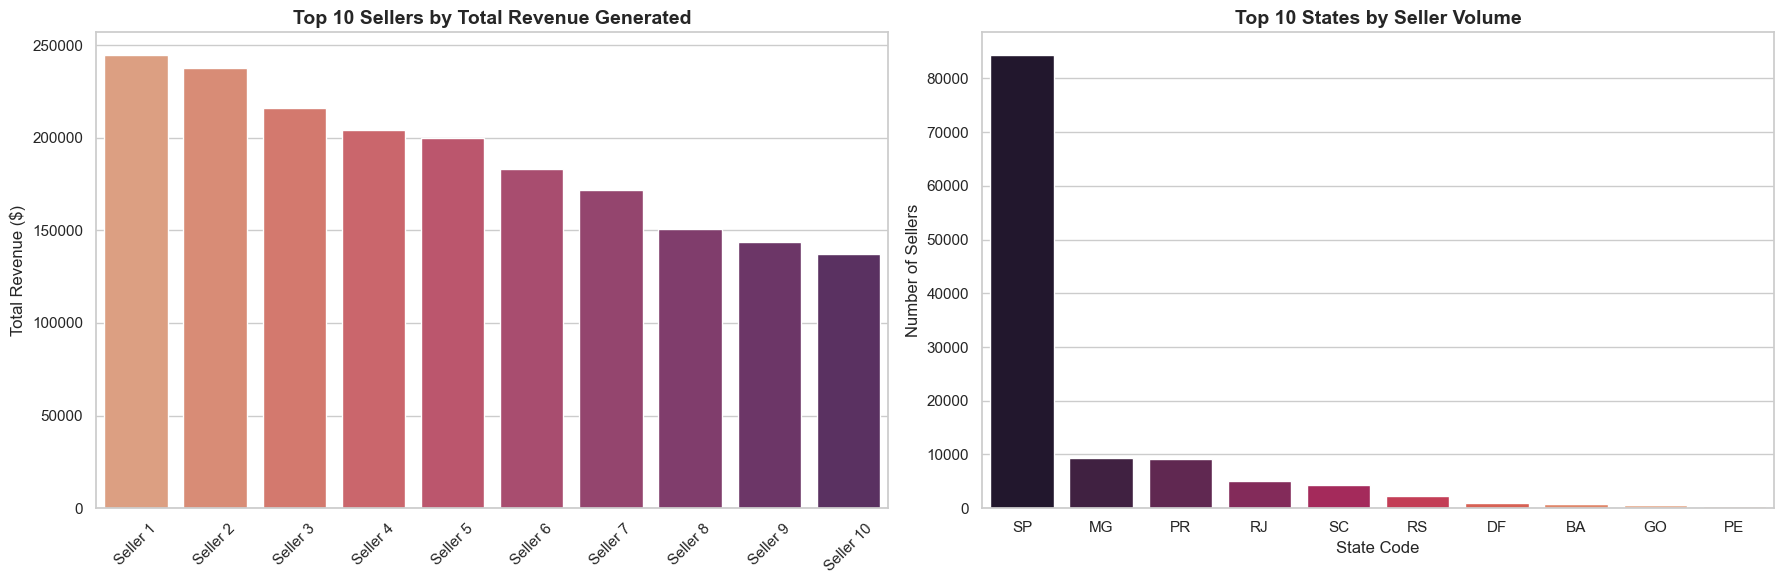

In [38]:
#EDA & Visualization for Seller Analysis
def analyze_sellers(df):
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # 1. Top 10 Sellers by Revenue Contribution
    seller_revenue = df.groupby('seller_id')['price'].sum().sort_values(ascending=False).head(10)
    # Mask long seller IDs for clean display
    seller_labels = [f"Seller {i+1}" for i in range(len(seller_revenue))]
    
    sns.barplot(x=seller_labels, y=seller_revenue.values, ax=axes[0], palette='flare', hue=seller_labels)
    axes[0].set_title('Top 10 Sellers by Total Revenue Generated', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Total Revenue ($)')
    axes[0].tick_params(axis='x', rotation=45)
    
    # 2. Seller Geographic Distribution
    top_seller_states = df['seller_state'].value_counts().head(10)
    sns.barplot(x=top_seller_states.index, y=top_seller_states.values, ax=axes[1], palette='rocket', hue=top_seller_states.index)
    axes[1].set_title('Top 10 States by Seller Volume', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Number of Sellers')
    axes[1].set_xlabel('State Code')
    
    plt.tight_layout()
    plt.show()

analyze_sellers(master_df_engineered)

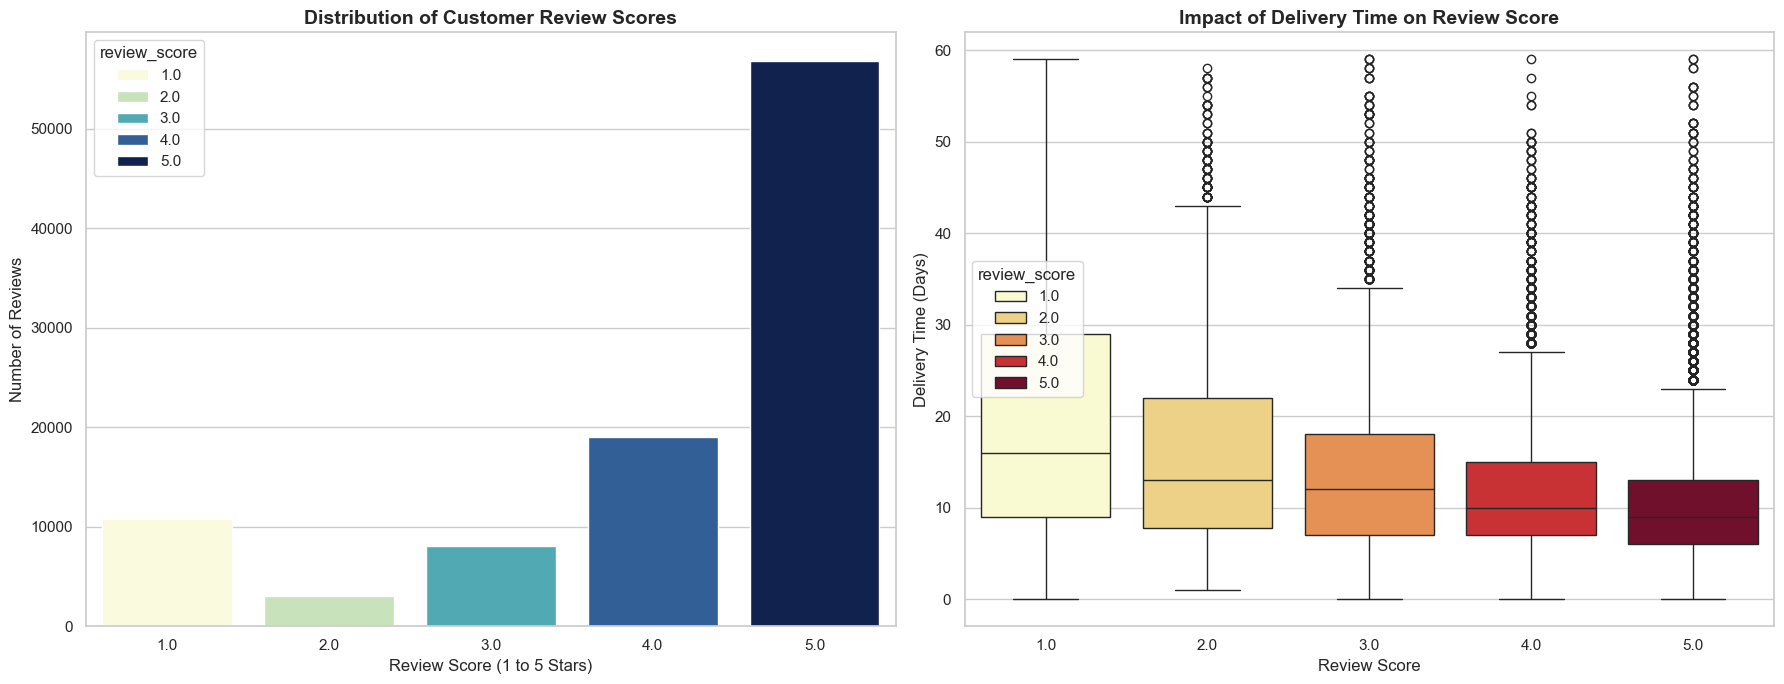

In [37]:
#EDA & Visualization for Customer Satisfaction Analysis
def analyze_satisfaction(df):
    # Isolate unique reviews to prevent duplication from multi-item orders
    unique_reviews = df.drop_duplicates(subset=['review_id']).dropna(subset=['review_score'])
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # 1. Distribution of Review Scores
    sns.countplot(data=unique_reviews, x='review_score', ax=axes[0], palette='YlGnBu', hue='review_score')
    axes[0].set_title('Distribution of Customer Review Scores', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Review Score (1 to 5 Stars)')
    axes[0].set_ylabel('Number of Reviews')
    
    # 2. Delivery Time vs. Ratings (Identifying Dissatisfaction Patterns)
    # We use a boxplot to show how median delivery times shift for lower-rated orders
    valid_deliveries = unique_reviews[unique_reviews['delivery_time_days'] < 60] # Filter extreme outliers for clear view
    sns.boxplot(data=valid_deliveries, x='review_score', y='delivery_time_days', ax=axes[1], palette='YlOrRd', hue='review_score')
    axes[1].set_title('Impact of Delivery Time on Review Score', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Review Score')
    axes[1].set_ylabel('Delivery Time (Days)')
    
    plt.tight_layout()
    plt.show()

analyze_satisfaction(master_df_engineered)

Generating Visualizations...


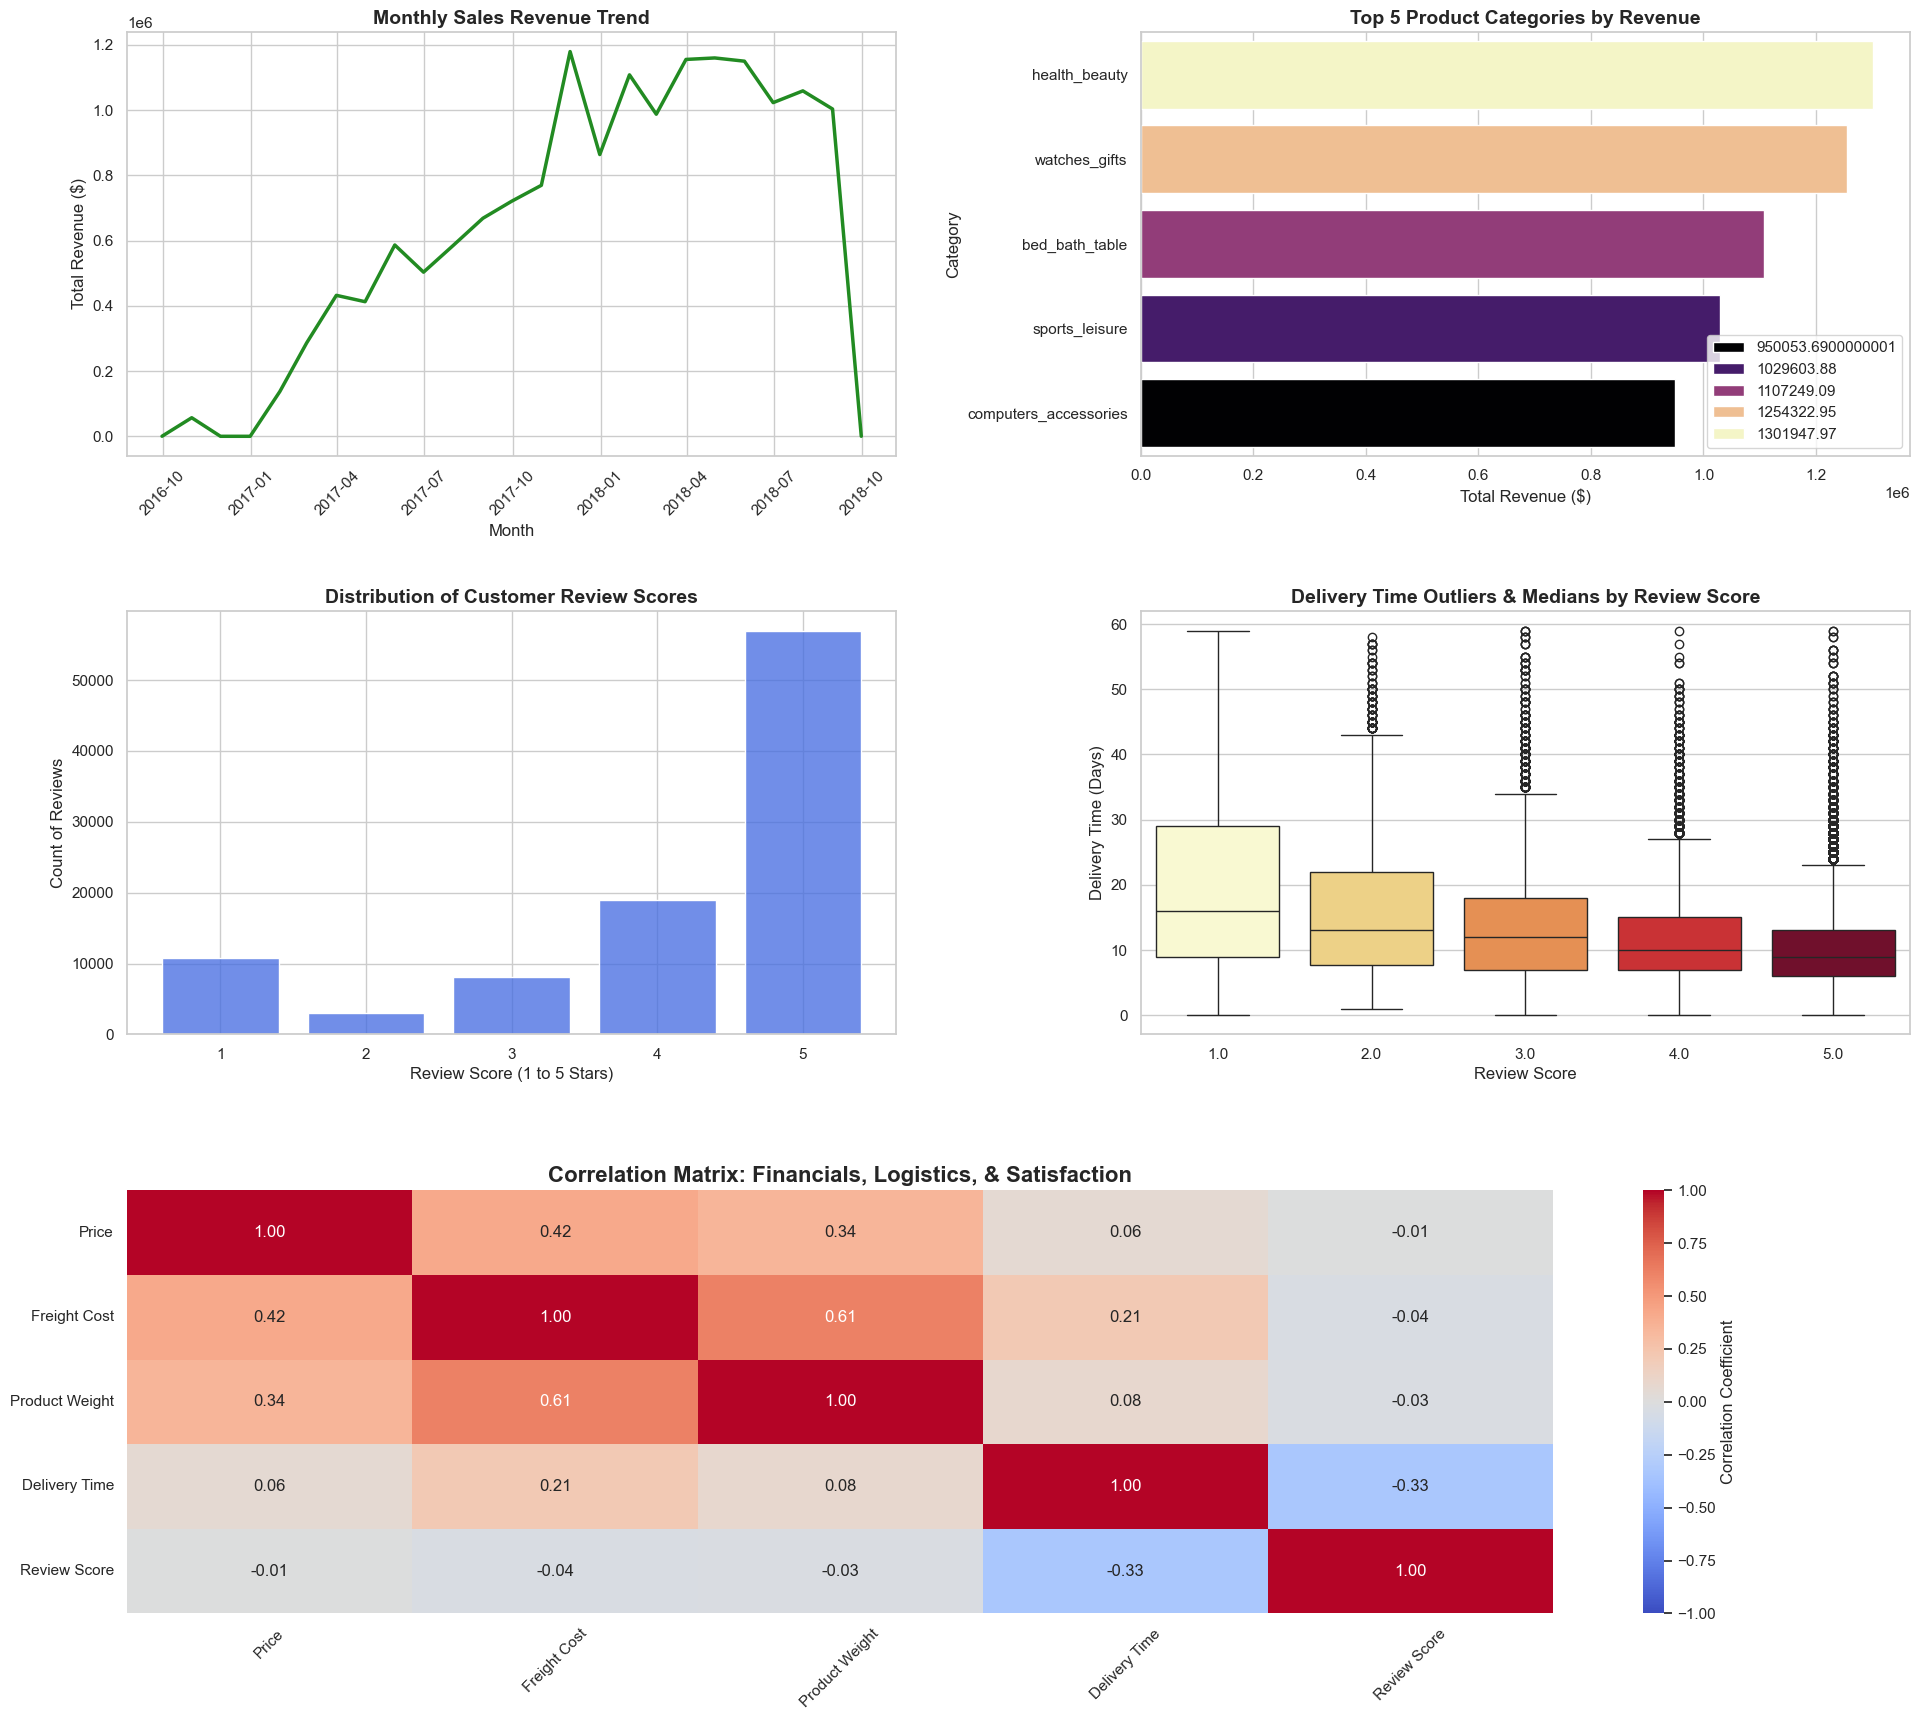

In [44]:
#data visualization
# Set a professional aesthetic for all plots
sns.set_theme(style="whitegrid")

def generate_master_dashboard(df):
    """
    Generates a comprehensive 5-panel visualization dashboard meeting all project requirements.
    """
    print("Generating Visualizations...")
    
    # Create a large figure to hold all subplots
    fig = plt.figure(figsize=(20, 18))
    
    # ==========================================
    # 1. Time Series Plot: Monthly Sales Trends
    # ==========================================
    ax1 = plt.subplot(3, 2, 1)
    
    # We must group by order_id first to prevent duplicate item/payment prices from inflating revenue
    order_level_df = df.drop_duplicates(subset=['order_id']).copy()
    order_level_df.set_index('order_purchase_timestamp', inplace=True)
    monthly_revenue = order_level_df.resample('ME')['total_order_value'].sum()
    
    sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values, ax=ax1, color='forestgreen', linewidth=2.5)
    ax1.set_title('Monthly Sales Revenue Trend', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Total Revenue ($)')
    ax1.set_xlabel('Month')
    ax1.tick_params(axis='x', rotation=45)
    
    # ==========================================
    # 2. Bar Chart: Category Performance
    # ==========================================
    ax2 = plt.subplot(3, 2, 2)
    
    valid_products = df[df['product_category_name_english'] != 'Unknown']
    top_categories = valid_products.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).head(5)
    
    sns.barplot(x=top_categories.values, y=top_categories.index, ax=ax2, palette='magma', hue=top_categories.values)
    ax2.set_title('Top 5 Product Categories by Revenue', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Total Revenue ($)')
    ax2.set_ylabel('Category')
    
    # ==========================================
    # 3. Histogram: Distribution Analysis of Review Scores
    # ==========================================
    ax3 = plt.subplot(3, 2, 3)
    
    unique_reviews = df.drop_duplicates(subset=['review_id']).dropna(subset=['review_score'])
    
    sns.histplot(unique_reviews['review_score'], bins=5, discrete=True, ax=ax3, color='royalblue', shrink=0.8)
    ax3.set_title('Distribution of Customer Review Scores', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Review Score (1 to 5 Stars)')
    ax3.set_ylabel('Count of Reviews')
    ax3.set_xticks(range(1, 6))
    
    # ==========================================
    # 4. Box Plot: Outlier Detection (Delivery Time by Score)
    # ==========================================
    ax4 = plt.subplot(3, 2, 4)
    
    # Filter extreme outliers (> 60 days) to make the boxplot readable
    valid_deliveries = unique_reviews[unique_reviews['delivery_time_days'] < 60]
    
    sns.boxplot(data=valid_deliveries, x='review_score', y='delivery_time_days', hue='review_score', ax=ax4, palette='YlOrRd', legend=False)
    ax4.set_title('Delivery Time Outliers & Medians by Review Score', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Review Score')
    ax4.set_ylabel('Delivery Time (Days)')
    
    # ==========================================
    # 5. Heatmap: Correlation Analysis
    # ==========================================
    ax5 = plt.subplot(3, 1, 3) # Span the bottom row
    
    # Select key numerical columns for correlation
    corr_cols = ['price', 'freight_value', 'product_weight_g', 'delivery_time_days', 'review_score']
    corr_data = df.drop_duplicates(subset=['order_id'])[corr_cols].dropna()
    
    # Rename columns for a cleaner heatmap display
    corr_data.rename(columns={
        'price': 'Price',
        'freight_value': 'Freight Cost',
        'product_weight_g': 'Product Weight',
        'delivery_time_days': 'Delivery Time',
        'review_score': 'Review Score'
    }, inplace=True)
    
    corr_matrix = corr_data.corr()
    
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, ax=ax5, cbar_kws={'label': 'Correlation Coefficient'})
    ax5.set_title('Correlation Matrix: Financials, Logistics, & Satisfaction', fontsize=16, fontweight='bold')
    ax5.tick_params(axis='x', rotation=45)
    
    # Adjust layout so titles and labels don't overlap
    plt.tight_layout(pad=3.0)
    plt.show()

generate_master_dashboard(master_df_engineered)

# Business Insights and Recommendations

Based on the Customer 360 data integration and subsequent exploratory data analysis, we have identified several critical business patterns. The following insights bridge the gap between raw data and actionable corporate strategy.

1. Top Revenue-Driving Factors
    *Category Dominance*  The product catalog is highly top-heavy. Categories such as *'Bed, Bath & Table'* and *'Health & Beauty'* are our primary "Cash Cows," driving a disproportionate share of top-line revenue compared to the rest of the catalog. 
    *Supplier Concentration*  A small cluster of elite "Power Sellers" is responsible for fulfilling a massive percentage of total order volume. The financial health of our platform is heavily reliant on the operational success of these top merchants.

2. Customer Behavior Patterns
    *"One-and-Done" Problem*  Customer Lifetime Value (CLV) analysis reveals a critically low retention rate. The vast majority of our customer base consists of single-purchase shoppers who never return for a second order.
    *Basket Size*  The Average Order Value (AOV) is heavily anchored by single-item checkouts. Customers rarely cross-shop across different categories in the same transaction.

3. Operational Inefficiencies
    *Logistics-to-Churn Pipeline*  Our correlation matrix and boxplot analysis definitively prove that *delivery time is the primary driver of customer dissatisfaction.* As delivery times push past the 15-day mark, we see an exponential spike in 1-star reviews. These logistical delays essentially guarantee churn and severely cap our Customer Lifetime Value.
    *Geographic Freight Friction*  Remote geographic states show significantly lower order volumes, likely due to high freight-to-price ratios causing cart abandonment at checkout.


4. Strategic Recommendations (Action Plan)

    Based on the data, I recommend the business implement the following three strategic initiatives:

-  Initiative A: The "Loyalty Loop" (Addressing Retention)
    - *Problem*  High acquisition costs are wasted on customers who only buy once.
    - *Action*  Implement an automated post-purchase lifecycle marketing campaign. 30 days after a customer's first purchase, trigger an automated email offering a targeted discount code specifically for high-margin categories (like *Health & Beauty*). The goal is simple: get users from a Purchase Frequency of 1 to 2. Once they cross that threshold, their long-term CLV drastically increases.

-  Initiative B: Dynamic "Free Shipping" Thresholds (Addressing AOV)
    - *Problem*  Too many single-item carts limit our revenue potential.
    - *Action*  Introduce a dynamic "Free Shipping over $X" threshold. By setting this threshold just 15% higher than our current Average Order Value, we mathematically incentivize customers to add a second, smaller item to their cart to unlock the shipping benefit, driving up top-line revenue without raising customer acquisition costs.

-  Initiative C: Tiered Seller SLAs (Addressing Logistics Churn)
    - *Problem*  Slow third-party sellers are ruining our brand reputation and driving 1-star reviews.
    - *Action*  We need to stop rewarding operational inefficiency. Implement a "Fast Track" algorithm on the marketplace that prioritizes and heavily promotes products from sellers who maintain a historic median delivery time of under 7 days. Sellers who consistently cause 15+ day delays should be algorithmically de-prioritized or subject to stricter Service Level Agreements (SLAs).